<a href="https://colab.research.google.com/github/melnikovknst/Invest-Portfolio-Optimization/blob/main/pipeline1_regime_aware_gmv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline 1 — Regime-Aware Shrinkage GMV

**Research objective.** Test whether a covariance forecast conditioned on latent market regimes improves the out-of-sample risk and implementation characteristics of the frozen Ledoit–Wolf Global Minimum Variance (GMV) baseline.

**Controlled comparison.** The investable universe, 252-day asset-return window, monthly rebalancing, 15% security cap, long-only constraint, turnover definition, and transaction costs are held fixed. Pipeline 1 changes only the covariance supplied to the existing GMV optimizer.

**Primary outcomes.** Annualized volatility, daily CVaR 95%, and maximum drawdown. Sharpe, Sortino, concentration, turnover, costs, solver stability, regime stability, and covariance conditioning are secondary outcomes.

**Interpretation rule.** Pipeline 1 is considered useful only if its risk improvement over the frozen baseline is economically material, statistically supported, robust to reasonable regime specifications, and not purchased through unacceptable turnover or concentration.

**Presentation map.** The notebook moves from data provenance to regime identification, covariance construction, a strictly walk-forward validation, statistical inference, regime-conditioned attribution, sensitivity analysis, and finally a guarded test. The final executive panel is designed to be shown directly to a research colleague.


## Locked protocol and hypotheses

The notebook uses a two-state Gaussian Hidden Markov Model (HMM): **calm** and **stress**. States are relabelled after every fit by realized-volatility level, preventing arbitrary HMM state numbers from changing the economic interpretation.

At every formation date (t):

1. all asset and regime inputs end strictly before (t);
2. the HMM is fitted only to the trailing market-feature history available at (t);
3. historical state responsibilities softly weight the asset returns used to estimate state covariances;
4. each state covariance is pooled toward the ordinary Ledoit–Wolf covariance;
5. filtered state probabilities are propagated through the transition matrix over the holding horizon;
6. the probability-weighted covariance is passed to the unchanged constrained-GMV optimizer.

**H1:** Regime-aware GMV has lower out-of-sample realized volatility than Ledoit–Wolf GMV.  
**H2:** Regime-aware GMV has lower out-of-sample CVaR 95% and maximum drawdown.  
**H3:** Any risk reduction survives transaction costs and does not materially worsen turnover, concentration, or weight stability.

Test-period execution is guarded by `RUN_LOCKED_TEST`. Keep it `False` until every Pipeline 1 choice has been frozen using train and validation data only.


In [ ]:
# Colab setup and reproducibility
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("hmmlearn") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "hmmlearn>=0.3,<0.4"])

import json
import logging
import math
import os
import platform
import shutil
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from hmmlearn.hmm import GaussianHMM
from scipy.optimize import minimize
from sklearn import __version__ as sklearn_version
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler

SEED = 20260902
TRADING_DAYS = 252
RNG = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5.5), "figure.dpi": 110})
logging.getLogger("hmmlearn").setLevel(logging.ERROR)

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn_version,
    "seed": SEED,
})


{'python': '3.13.15', 'numpy': '2.1.3', 'pandas': '2.2.3', 'scikit_learn': '1.6.1', 'seed': 20260902}


In [ ]:
@dataclass(frozen=True)
class BacktestConfig:
    lookback: int = 252
    rebalance: Literal["M", "Q"] = "M"
    max_weight: float = 0.15
    min_observations: int = 202
    max_missing_fraction: float = 0.05
    transaction_cost_bps: float = 10.0

    @property
    def cost_rate(self) -> float:
        return self.transaction_cost_bps / 10_000.0


@dataclass(frozen=True)
class RegimeConfig:
    n_states: int = 2
    hmm_lookback: int = 2520
    min_hmm_observations: int = 756
    covariance_lookback: int = 252
    vol_window: int = 20
    drawdown_window: int = 63
    correlation_window: int = 60
    holding_horizon: int = 21
    random_restarts: int = 5
    max_iterations: int = 500
    tolerance: float = 1e-4
    min_covar: float = 1e-6
    pooling_strength: float = 1.0
    include_between_state_mean: bool = False


@dataclass
class BacktestResult:
    strategy: str
    config: BacktestConfig
    returns: pd.DataFrame
    target_weights: pd.DataFrame
    diagnostics: pd.DataFrame


BASELINE_CONFIG = BacktestConfig()
REGIME_CONFIG = RegimeConfig()
RUN_LOCKED_TEST = False
BOOTSTRAP_REPLICATIONS = 2_000
BOOTSTRAP_BLOCK_LENGTH = 20

print("Frozen baseline:", asdict(BASELINE_CONFIG))
print("Frozen Pipeline 1:", asdict(REGIME_CONFIG))
print("Locked test enabled:", RUN_LOCKED_TEST)


Frozen baseline: {'lookback': 252, 'rebalance': 'M', 'max_weight': 0.15, 'min_observations': 202, 'max_missing_fraction': 0.05, 'transaction_cost_bps': 10.0}
Frozen Pipeline 1: {'n_states': 2, 'hmm_lookback': 2520, 'min_hmm_observations': 756, 'covariance_lookback': 252, 'vol_window': 20, 'drawdown_window': 63, 'correlation_window': 60, 'holding_horizon': 21, 'random_restarts': 5, 'max_iterations': 500, 'tolerance': 0.0001, 'min_covar': 1e-06, 'pooling_strength': 1.0, 'include_between_state_mean': False}
Locked test enabled: False


## Data provenance and limitations

The notebook clones the same repository used by the baseline and reads the immutable `train.csv`, `val.csv`, and `test.csv` files. Adjusted prices are converted into simple total returns. No returns are forward-filled, backfilled, winsorized, or deleted.

The supplied panel contains 50 surviving securities. Point-in-time eligibility is enforced inside that panel, but the data cannot recover securities that disappeared before the panel was assembled. Consequently, complete elimination of survivorship bias requires historical constituent and delisting data not present in the repository.

Market-state features are deliberately constructed from the supplied panel so the first experiment has no additional external-data dependency. A broad index, VIX, market liquidity, and credit-spread variables belong in robustness extensions rather than the primary specification.


In [ ]:
REPO_URL = "https://github.com/melnikovknst/Invest-Portfolio-Optimization.git"
COLAB_ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
REPO_DIR = COLAB_ROOT / "Invest-Portfolio-Optimization"
ARTICLE_DIR = COLAB_ROOT / "pipeline1_article_outputs"
FIGURE_DIR = ARTICLE_DIR / "figures"
TABLE_DIR = ARTICLE_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

if not (REPO_DIR / ".git").exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)

DATA_DIR = REPO_DIR / "data"
SPLIT_FILES = {"train": "train.csv", "validation": "val.csv", "test": "test.csv"}


def normalize_column(column: str) -> str:
    return "".join(ch for ch in column.lower() if ch.isalnum())


def detect_schema(frame: pd.DataFrame) -> dict[str, str]:
    normalized = {column: normalize_column(column) for column in frame.columns}

    def choose(candidates: tuple[str, ...], field: str) -> str:
        matches = [column for column, token in normalized.items() if token in candidates]
        if len(matches) != 1:
            raise ValueError(f"Expected one {field} column, found {matches}.")
        return matches[0]

    date = choose(("date", "datetime", "timestamp", "tradedate", "pricedate"), "date")
    asset = choose(("ticker", "symbol", "asset", "assetid", "security", "ric"), "asset")
    adjusted = [column for column, token in normalized.items() if token in {
        "adjclose", "adjustedclose", "adjustedprice", "adjprice", "totalreturnprice"
    }]
    ordinary = [column for column, token in normalized.items() if token in {"close", "closeprice", "price"}]
    prices = adjusted or ordinary
    if len(prices) != 1:
        raise ValueError(f"Expected one unambiguous price column, found {prices}.")
    return {"date": date, "asset": asset, "price": prices[0]}


def prepare_split(frame: pd.DataFrame) -> pd.DataFrame:
    schema = detect_schema(frame)
    output = frame.rename(columns={
        schema["date"]: "date", schema["asset"]: "asset", schema["price"]: "price"
    }).copy()
    output["date"] = pd.to_datetime(output["date"], errors="raise")
    output["asset"] = output["asset"].astype(str).str.strip()
    output["price"] = pd.to_numeric(output["price"], errors="raise")
    return output.sort_values(["date", "asset"]).reset_index(drop=True)


raw_splits = {name: pd.read_csv(DATA_DIR / filename) for name, filename in SPLIT_FILES.items()}
clean_splits = {name: prepare_split(frame) for name, frame in raw_splits.items()}
split_ranges = pd.DataFrame({
    name: {
        "start": frame["date"].min(), "end": frame["date"].max(),
        "assets": frame["asset"].nunique(), "rows": len(frame)
    }
    for name, frame in clean_splits.items()
}).T

assert split_ranges.loc["train", "end"] < split_ranges.loc["validation", "start"]
assert split_ranges.loc["validation", "end"] < split_ranges.loc["test", "start"]

combined = pd.concat(
    [clean_splits[name].assign(split=name) for name in ("train", "validation", "test")],
    ignore_index=True,
).sort_values(["date", "asset"])
if combined.duplicated(["date", "asset"]).any():
    raise ValueError("Duplicate date-asset keys prevent an unambiguous return panel.")

price_matrix = combined.pivot(index="date", columns="asset", values="price").sort_index()
simple_returns = price_matrix.pct_change(fill_method=None)
split_dates = {
    name: pd.DatetimeIndex(sorted(frame["date"].unique()))
    for name, frame in clean_splits.items()
}

data_audit = pd.DataFrame({
    "value": {
        "dates": len(price_matrix),
        "assets": price_matrix.shape[1],
        "duplicate_date_asset_keys": int(combined.duplicated(["date", "asset"]).sum()),
        "missing_price_cells": int(price_matrix.isna().sum().sum()),
        "nonpositive_prices": int(price_matrix.le(0).sum().sum()),
        "absolute_returns_over_20pct": int(simple_returns.abs().gt(0.20).sum().sum()),
    }
})
display(split_ranges)
display(data_audit)


,start,end,assets,rows
train,2000-01-03 00:00:00,2016-12-30 00:00:00,50,213850
validation,2017-01-03 00:00:00,2020-12-31 00:00:00,50,50350
test,2021-01-04 00:00:00,2026-02-20 00:00:00,50,64450


,value
dates,6573
assets,50
duplicate_date_asset_keys,0
missing_price_cells,0
nonpositive_prices,0
absolute_returns_over_20pct,271


### Extreme-return audit

Adjusted-price returns above 20% in absolute value are not silently removed. They are listed below so that genuine jumps, corporate-action artifacts, and possible data errors can be distinguished before any article claim is finalized. The primary experiment remains unchanged; this is an audit, not an ex-post cleaning rule.


In [ ]:
stacked_returns = simple_returns.stack().rename("return")
stacked_returns.index.names = ["date", "asset"]
extreme_return_events = (
    stacked_returns.loc[stacked_returns.abs() > 0.20]
    .reset_index()
    .assign(absolute_return=lambda frame: frame["return"].abs())
    .sort_values("absolute_return", ascending=False)
)
extreme_return_summary = (
    extreme_return_events.groupby("asset")
    .agg(events=("return", "size"), maximum_absolute_return=("absolute_return", "max"))
    .sort_values(["events", "maximum_absolute_return"], ascending=False)
)
print(f"Extreme adjusted-price returns requiring review: {len(extreme_return_events):,}")
display(extreme_return_events.head(25))
display(extreme_return_summary.head(20))
extreme_return_events.to_csv(TABLE_DIR / "extreme_return_audit.csv", index=False)
extreme_return_summary.to_csv(TABLE_DIR / "extreme_return_summary.csv")


Extreme adjusted-price returns requiring review: 271


,date,asset,return,absolute_return
200,2009-03-16,AIG,0.658188,0.658188
218,2009-08-05,AIG,0.627059,0.627059
141,2008-09-15,AIG,-0.607889,0.607889
178,2008-11-24,C,0.578530,0.578530
240,2020-03-09,APA,-0.538979,0.538979
233,2016-04-22,AMD,0.522901,0.522901
24,2000-09-29,AAPL,-0.512500,0.512500
63,2001-09-26,AES,-0.494832,0.494832
4,2000-03-06,A,0.472347,0.472347
107,2002-11-21,AKAM,0.456954,0.456954


,events,maximum_absolute_return
asset,,
AKAM,34,0.456954
AIG,31,0.658188
BKNG,31,0.423301
AES,17,0.494832
BAC,17,0.353480
C,14,0.578530
AMD,14,0.522901
AMZN,14,0.355556
BIIB,13,0.439739


## Market-state features

The primary HMM specification uses four backward-looking features:

| Feature | Definition | Economic interpretation |
|---|---|---|
| Market return | Cross-sectional equal-weight return | Direction of the common market component |
| Realized volatility | 20-day annualized volatility of the market proxy | Current risk intensity |
| Drawdown | 63-day drawdown of the market-proxy wealth index | Accumulated downside state |
| Average correlation | Mean off-diagonal correlation over 60 days | Strength of common movement and diversification pressure |

All four variables are standardized inside each formation-date HMM training sample. No full-sample scaling is allowed.


,minimum,median,maximum,missing_after_construction
feature,,,,
market_return,-0.126274,0.000943,0.116910,0
realized_volatility,0.034976,0.144236,1.054555,0
drawdown,-0.467568,-0.017550,0.000000,0
average_correlation,0.045307,0.308582,0.774309,0


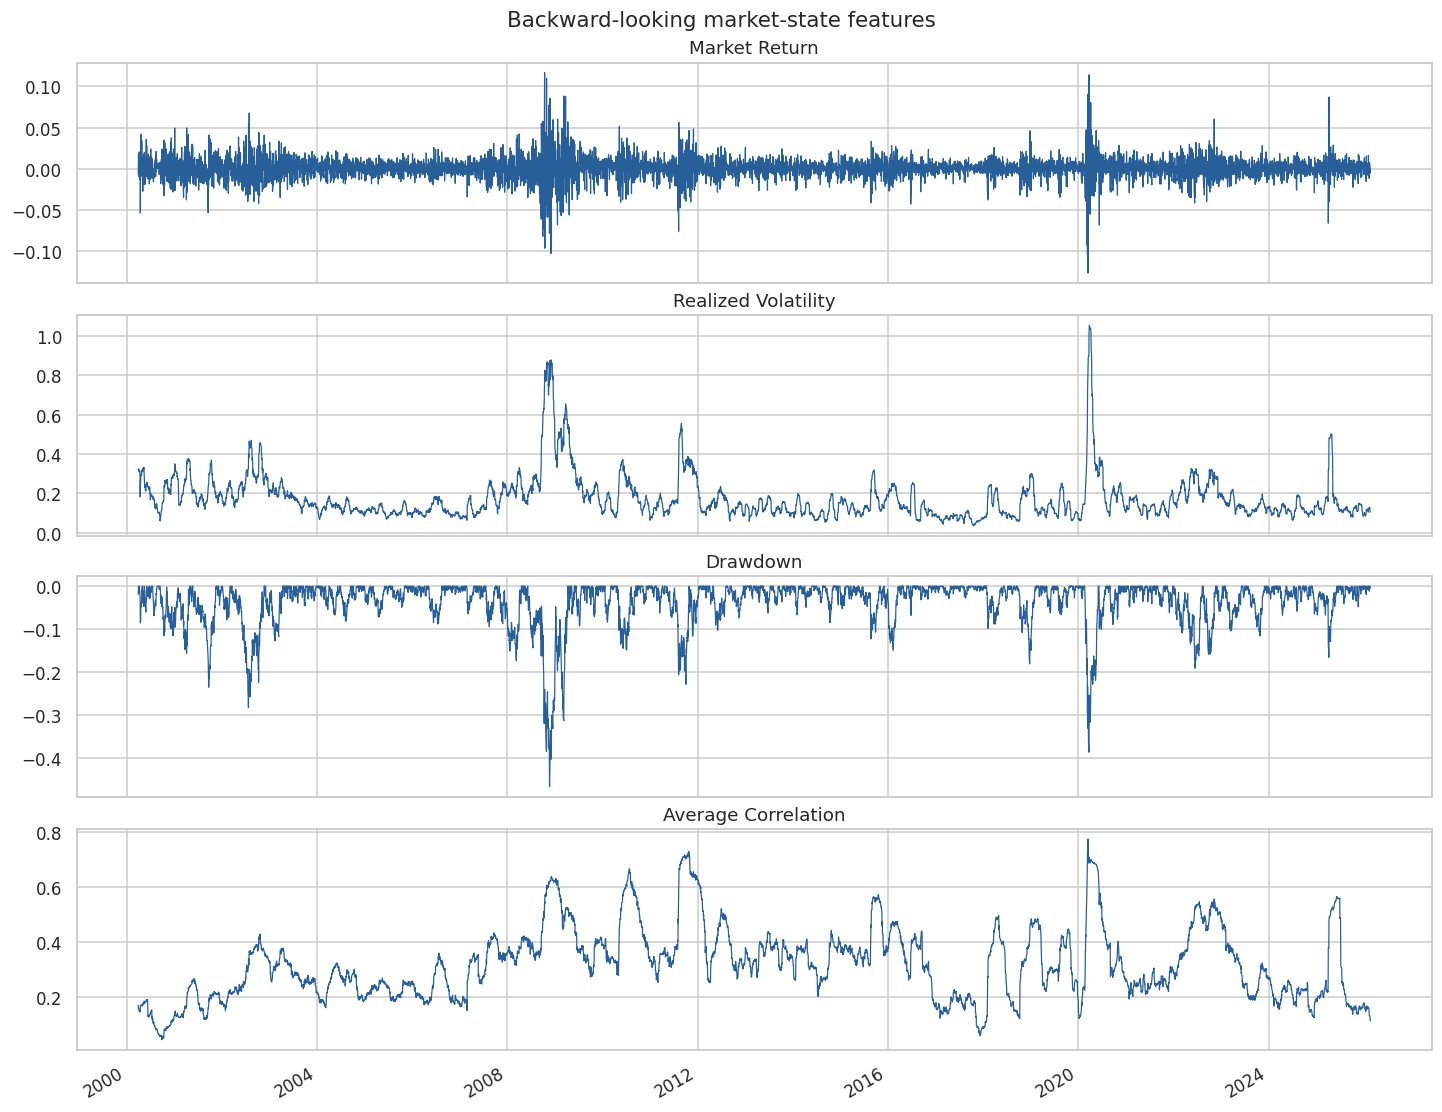

In [ ]:
def rolling_average_correlation(returns: pd.DataFrame, window: int) -> pd.Series:
    '''Exact rolling mean off-diagonal correlation for a complete return panel.'''
    complete = returns.dropna(how="any")
    x = complete.to_numpy(dtype=float)
    result = np.full(len(complete), np.nan)
    if len(complete) < window or x.shape[1] < 2:
        return pd.Series(result, index=complete.index, name="average_correlation")

    rolling_sum = x[:window].sum(axis=0)
    rolling_cross = x[:window].T @ x[:window]
    for end in range(window - 1, len(complete)):
        if end >= window:
            old = x[end - window]
            new = x[end]
            rolling_sum += new - old
            rolling_cross += np.outer(new, new) - np.outer(old, old)
        covariance = (rolling_cross - np.outer(rolling_sum, rolling_sum) / window) / (window - 1)
        variance = np.clip(np.diag(covariance), 1e-18, None)
        correlation = covariance / np.sqrt(np.outer(variance, variance))
        upper = correlation[np.triu_indices_from(correlation, k=1)]
        result[end] = np.nanmean(upper)
    return pd.Series(result, index=complete.index, name="average_correlation")


def build_regime_features(returns: pd.DataFrame, config: RegimeConfig) -> pd.DataFrame:
    complete = returns.dropna(how="any")
    market_return = complete.mean(axis=1).rename("market_return")
    realized_volatility = (
        market_return.rolling(config.vol_window, min_periods=config.vol_window).std(ddof=1)
        * np.sqrt(TRADING_DAYS)
    ).rename("realized_volatility")
    wealth = (1.0 + market_return).cumprod()
    rolling_peak = wealth.rolling(config.drawdown_window, min_periods=1).max()
    drawdown = (wealth / rolling_peak - 1.0).rename("drawdown")
    average_correlation = rolling_average_correlation(complete, config.correlation_window)
    features = pd.concat(
        [market_return, realized_volatility, drawdown, average_correlation], axis=1
    ).replace([np.inf, -np.inf], np.nan).dropna()
    return features


regime_features = build_regime_features(simple_returns, REGIME_CONFIG)
feature_definitions = pd.DataFrame({
    "feature": regime_features.columns,
    "minimum": regime_features.min(),
    "median": regime_features.median(),
    "maximum": regime_features.max(),
    "missing_after_construction": regime_features.isna().sum(),
}).set_index("feature")
display(feature_definitions)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True, constrained_layout=True)
for axis, column in zip(axes, regime_features.columns):
    regime_features[column].plot(ax=axis, lw=0.8, color="#295f98")
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("")
fig.suptitle("Backward-looking market-state features", fontsize=14)
fig.savefig(FIGURE_DIR / "01_market_state_features.png", dpi=180, bbox_inches="tight")
plt.show()


## HMM estimation and state identification

A Gaussian HMM is fitted with several deterministic random restarts. The converged model with the largest training log-likelihood is retained. The state with the greater probability-weighted realized volatility is labelled **stress**; the other state is labelled **calm**.

For dates inside the estimation sample, smoothed responsibilities are legitimate because all those observations are already known at formation date (t). The probability attached to the final training observation is filtered: there are no later observations inside the sample that can influence it.


,market_return,realized_volatility,drawdown,average_correlation,occupancy,expected_duration_days
calm,0.001062,0.105583,-0.007587,0.304083,0.64581,52.437530
stress,-0.000004,0.244966,-0.068865,0.452565,0.35419,28.774483


,to_calm,to_stress
from_calm,0.980930,0.019070
from_stress,0.034753,0.965247


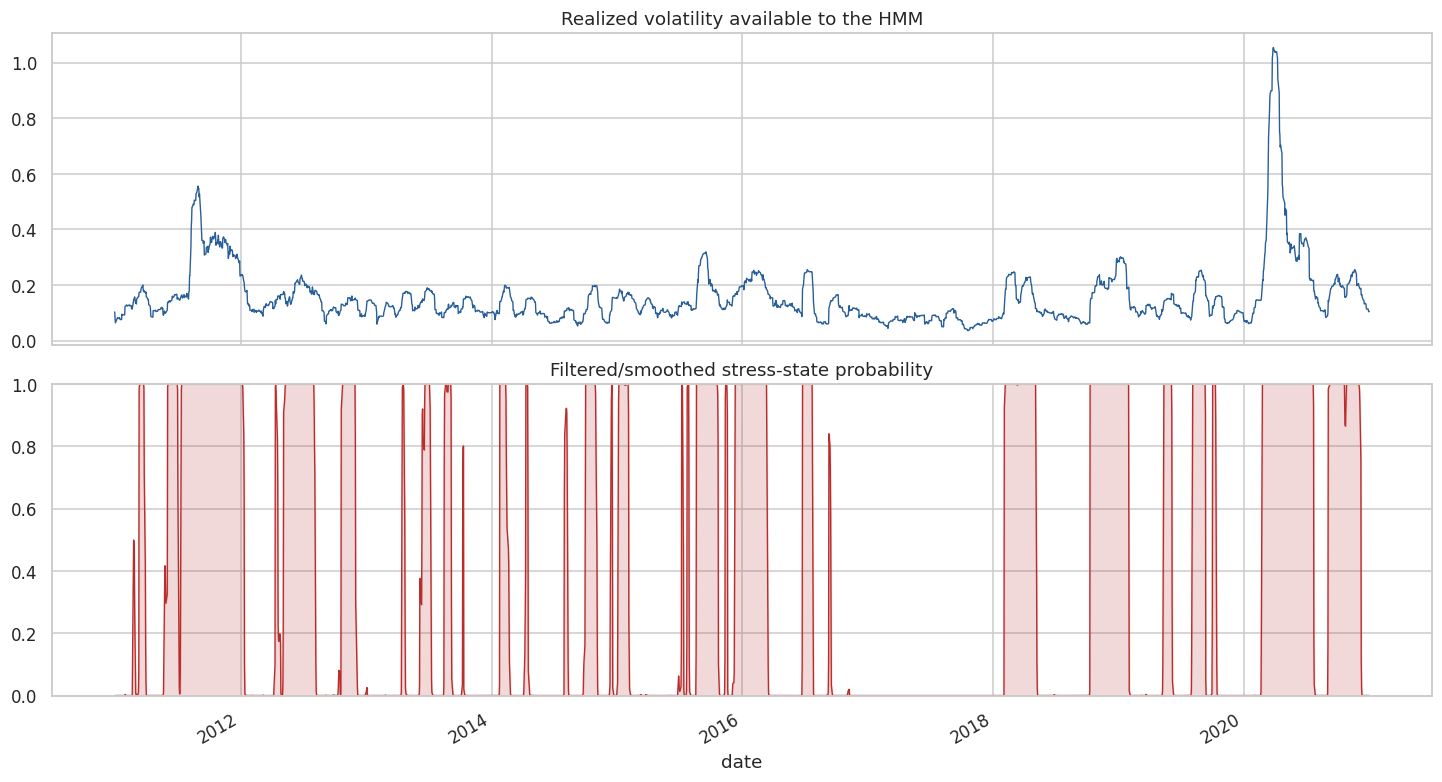

In [ ]:
def fit_regime_model(
    features: pd.DataFrame,
    formation_date: pd.Timestamp,
    config: RegimeConfig,
) -> dict:
    history = features.loc[features.index < formation_date].tail(config.hmm_lookback)
    if len(history) < config.min_hmm_observations:
        raise ValueError(
            f"Only {len(history)} HMM observations before {formation_date.date()}, "
            f"below {config.min_hmm_observations}."
        )
    assert history.index.max() < formation_date

    scaler = StandardScaler().fit(history)
    z = scaler.transform(history)
    best_model = None
    best_score = -np.inf
    attempts = []
    for restart in range(config.random_restarts):
        model = GaussianHMM(
            n_components=config.n_states,
            covariance_type="full",
            n_iter=config.max_iterations,
            tol=config.tolerance,
            min_covar=config.min_covar,
            random_state=SEED + restart,
        )
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(z)
                score = float(model.score(z))
            converged = bool(model.monitor_.converged)
            attempts.append({"restart": restart, "score": score, "converged": converged})
            if converged and score > best_score:
                best_model, best_score = model, score
        except Exception as exc:
            attempts.append({"restart": restart, "score": np.nan, "converged": False, "error": str(exc)})
    if best_model is None:
        raise RuntimeError(f"No converged HMM fit at {formation_date.date()}: {attempts}")

    gamma = best_model.predict_proba(z)
    gamma_frame = pd.DataFrame(
        gamma, index=history.index, columns=[f"state_{k}" for k in range(config.n_states)]
    )
    state_feature_means = pd.DataFrame(index=range(config.n_states), columns=history.columns, dtype=float)
    for state in range(config.n_states):
        weights = gamma[:, state]
        state_feature_means.loc[state] = np.average(history, axis=0, weights=weights)

    stress_state = int(state_feature_means["realized_volatility"].astype(float).idxmax())
    calm_state = int(next(state for state in range(config.n_states) if state != stress_state))
    return {
        "model": best_model,
        "scaler": scaler,
        "history": history,
        "responsibilities": gamma_frame,
        "state_feature_means": state_feature_means,
        "stress_state": stress_state,
        "calm_state": calm_state,
        "log_likelihood": best_score,
        "attempts": pd.DataFrame(attempts),
    }


diagnostic_formation_date = split_dates["test"][0]
diagnostic_fit = fit_regime_model(regime_features, diagnostic_formation_date, REGIME_CONFIG)
stress_state = diagnostic_fit["stress_state"]
calm_state = diagnostic_fit["calm_state"]
daily_probabilities = diagnostic_fit["responsibilities"].rename(columns={
    f"state_{calm_state}": "calm_probability",
    f"state_{stress_state}": "stress_probability",
})
transition = pd.DataFrame(
    diagnostic_fit["model"].transmat_[np.ix_([calm_state, stress_state], [calm_state, stress_state])],
    index=["from_calm", "from_stress"], columns=["to_calm", "to_stress"],
)
state_summary = diagnostic_fit["state_feature_means"].loc[[calm_state, stress_state]].copy()
state_summary.index = ["calm", "stress"]
state_summary["occupancy"] = [
    daily_probabilities["calm_probability"].mean(),
    daily_probabilities["stress_probability"].mean(),
]
state_summary["expected_duration_days"] = [
    1.0 / max(1e-9, 1.0 - transition.loc["from_calm", "to_calm"]),
    1.0 / max(1e-9, 1.0 - transition.loc["from_stress", "to_stress"]),
]
display(state_summary)
display(transition)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, constrained_layout=True)
regime_features.loc[daily_probabilities.index, "realized_volatility"].plot(
    ax=axes[0], color="#295f98", lw=0.9
)
axes[0].set_title("Realized volatility available to the HMM")
daily_probabilities["stress_probability"].plot(ax=axes[1], color="#ba2d2d", lw=0.9)
axes[1].fill_between(
    daily_probabilities.index, 0, daily_probabilities["stress_probability"],
    color="#ba2d2d", alpha=0.18,
)
axes[1].set_ylim(0, 1)
axes[1].set_title("Filtered/smoothed stress-state probability")
fig.savefig(FIGURE_DIR / "02_stress_probability.png", dpi=180, bbox_inches="tight")
plt.show()


## Regime-weighted covariance

For state (k), historical return observations receive HMM responsibility (gamma_{s,k}). The effective sample size is

\[
n_{\mathrm{eff},k}=\frac{(\sum_s\gamma_{s,k})^2}{\sum_s\gamma_{s,k}^2}.
\]

A probability-weighted covariance (S_k) is pooled toward the ordinary Ledoit–Wolf covariance (\Sigma_{LW}):

\[
\widetilde\Sigma_k=\alpha_k S_k+(1-\alpha_k)\Sigma_{LW},\qquad
\alpha_k=\frac{n_{\mathrm{eff},k}}{n_{\mathrm{eff},k}+\kappa N}.
\]

Current probabilities are propagated through the HMM transition matrix across the 21-day holding horizon. Their average produces the final forecast:

\[
\Sigma^{regime}_t=\sum_k \bar p_{t+1:t+H,k}\widetilde\Sigma_{k,t}.
\]

The primary specification excludes between-state mean terms, keeping the experiment focused on risk estimation rather than noisy conditional-return forecasts.


In [ ]:
def weighted_covariance(values: np.ndarray, weights: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    weights = np.asarray(weights, dtype=float)
    total = float(weights.sum())
    square_total = float(np.square(weights).sum())
    if total <= 0 or square_total <= 0:
        raise ValueError("State weights have zero mass.")
    effective_n = total * total / square_total
    mean = np.average(values, axis=0, weights=weights)
    centered = values - mean
    denominator = total - square_total / total
    if denominator <= 0:
        raise ValueError("Weighted covariance has non-positive degrees of freedom.")
    covariance = (centered * weights[:, None]).T @ centered / denominator
    return (covariance + covariance.T) / 2, mean, effective_n


def forecast_average_probabilities(current: np.ndarray, transition: np.ndarray, horizon: int) -> np.ndarray:
    probability = np.asarray(current, dtype=float).copy()
    total = np.zeros_like(probability)
    for _ in range(horizon):
        probability = probability @ transition
        total += probability
    forecast = total / horizon
    return forecast / forecast.sum()


def make_positive_definite(covariance: np.ndarray) -> tuple[np.ndarray, float]:
    covariance = (covariance + covariance.T) / 2
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    scale = max(float(np.median(np.diag(covariance))), 1e-12)
    floor = scale * 1e-8
    clipped = np.maximum(eigenvalues, floor)
    repaired = (eigenvectors * clipped) @ eigenvectors.T
    return (repaired + repaired.T) / 2, float(eigenvalues.min())


def estimate_ledoit_wolf(history: pd.DataFrame) -> tuple[np.ndarray, dict]:
    values = history.to_numpy(dtype=float)
    fitted = LedoitWolf(assume_centered=False, store_precision=False).fit(values)
    covariance = (fitted.covariance_ + fitted.covariance_.T) / 2
    return covariance, {
        "global_shrinkage": float(fitted.shrinkage_),
        "global_condition_number": float(np.linalg.cond(covariance)),
    }


def estimate_regime_covariance(
    history: pd.DataFrame,
    features: pd.DataFrame,
    formation_date: pd.Timestamp,
    config: RegimeConfig,
) -> tuple[np.ndarray, dict]:
    global_covariance, global_diag = estimate_ledoit_wolf(history)
    fit = fit_regime_model(features, formation_date, config)
    gamma = fit["responsibilities"].reindex(history.index)
    if gamma.isna().any().any():
        missing = history.index[gamma.isna().any(axis=1)]
        raise ValueError(f"Regime responsibilities missing for {len(missing)} covariance observations.")

    values = history.to_numpy(dtype=float)
    state_covariances = []
    state_means = []
    state_effective_n = []
    state_pooling = []
    for state in range(config.n_states):
        raw_covariance, mean, effective_n = weighted_covariance(
            values, gamma[f"state_{state}"].to_numpy()
        )
        alpha = effective_n / (effective_n + config.pooling_strength * history.shape[1])
        pooled = alpha * raw_covariance + (1.0 - alpha) * global_covariance
        state_covariances.append((pooled + pooled.T) / 2)
        state_means.append(alpha * mean)
        state_effective_n.append(effective_n)
        state_pooling.append(alpha)

    current_probability = gamma.iloc[-1].to_numpy(dtype=float)
    forecast_probability = forecast_average_probabilities(
        current_probability, fit["model"].transmat_, config.holding_horizon
    )
    covariance = sum(
        forecast_probability[state] * state_covariances[state]
        for state in range(config.n_states)
    )
    if config.include_between_state_mean:
        mixture_mean = sum(
            forecast_probability[state] * state_means[state]
            for state in range(config.n_states)
        )
        for state in range(config.n_states):
            difference = state_means[state] - mixture_mean
            covariance += forecast_probability[state] * np.outer(difference, difference)

    covariance, pre_repair_min_eigenvalue = make_positive_definite(covariance)
    stress = fit["stress_state"]
    calm = fit["calm_state"]
    diagnostics = {
        **global_diag,
        "hmm_log_likelihood": fit["log_likelihood"],
        "hmm_history_start": fit["history"].index.min(),
        "hmm_history_end": fit["history"].index.max(),
        "hmm_observations": len(fit["history"]),
        "hmm_converged": True,
        "hmm_fallback": False,
        "current_stress_probability": current_probability[stress],
        "forecast_stress_probability": forecast_probability[stress],
        "calm_effective_observations": state_effective_n[calm],
        "stress_effective_observations": state_effective_n[stress],
        "calm_pooling_alpha": state_pooling[calm],
        "stress_pooling_alpha": state_pooling[stress],
        "calm_to_stress_probability": fit["model"].transmat_[calm, stress],
        "stress_persistence": fit["model"].transmat_[stress, stress],
        "regime_condition_number": float(np.linalg.cond(covariance)),
        "pre_repair_min_eigenvalue": pre_repair_min_eigenvalue,
    }
    return covariance, diagnostics


## Frozen optimizer and walk-forward engine

The following cells retain the baseline’s core mechanics: point-in-time eligibility, constrained GMV, capped-simplex projection, drift-aware turnover, and proportional transaction costs. The only strategy-specific branch is covariance construction.


In [ ]:
def get_eligible_universe(
    returns: pd.DataFrame,
    prices: pd.DataFrame,
    formation_date: pd.Timestamp,
    config: BacktestConfig,
) -> tuple[list[str], pd.DataFrame]:
    history = returns.loc[returns.index < formation_date].tail(config.lookback)
    prior_prices = prices.loc[prices.index < formation_date]
    if history.empty or prior_prices.empty:
        raise ValueError(f"No strictly prior history for {formation_date.date()}.")
    observation_count = history.notna().sum()
    missing_fraction = history.isna().mean()
    last_price = prior_prices.iloc[-1]
    eligible_mask = (
        observation_count.ge(config.min_observations)
        & missing_fraction.le(config.max_missing_fraction)
        & last_price.notna() & last_price.gt(0)
    )
    eligible = sorted(observation_count.index[eligible_mask].tolist())
    joint_history = history[eligible].dropna(how="any")
    if not eligible or len(joint_history) < config.min_observations:
        raise ValueError(f"Insufficient eligible history at {formation_date.date()}.")
    assert joint_history.index.max() < formation_date
    return eligible, joint_history


def make_rebalance_dates(index: pd.DatetimeIndex, frequency: Literal["M", "Q"]) -> pd.DatetimeIndex:
    periods = index.to_period(frequency)
    return index[~periods.duplicated()]


def project_capped_simplex(values: np.ndarray, cap: float) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    if len(values) * cap < 1 - 1e-12:
        raise ValueError("Weight cap is infeasible.")
    lower, upper = values.min() - cap, values.max()
    for _ in range(100):
        midpoint = (lower + upper) / 2
        projected = np.clip(values - midpoint, 0.0, cap)
        if projected.sum() > 1.0:
            lower = midpoint
        else:
            upper = midpoint
    projected = np.clip(values - (lower + upper) / 2, 0.0, cap)
    projected /= projected.sum()
    return projected


def solve_gmv(covariance: np.ndarray, assets: list[str], max_weight: float) -> tuple[pd.Series, dict]:
    n_assets = len(assets)
    if n_assets * max_weight < 1 - 1e-10:
        raise ValueError("Infeasible cap for the eligible universe.")
    variance_scale = float(np.median(np.diag(covariance)))
    if not np.isfinite(variance_scale) or variance_scale <= 0:
        raise ValueError("Covariance has no finite positive variance scale.")
    scaled = covariance / variance_scale
    initial = np.full(n_assets, 1.0 / n_assets)
    objective = lambda w: float(np.dot(np.dot(w, scaled), w))
    gradient = lambda w: 2.0 * np.dot(scaled, w)
    result = minimize(
        objective, initial, jac=gradient, method="SLSQP",
        bounds=[(0.0, max_weight)] * n_assets,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1.0,
                     "jac": lambda w: np.ones_like(w)},
        options={"ftol": 1e-12, "maxiter": 1_000, "disp": False},
    )
    feasible = (
        result.success and abs(result.x.sum() - 1.0) <= 1e-7
        and result.x.min() >= -1e-8 and result.x.max() <= max_weight + 1e-8
    )
    if feasible:
        weights = project_capped_simplex(result.x, max_weight)
    else:
        weights = initial
        if weights.max() > max_weight + 1e-12:
            raise RuntimeError(f"Solver and equal-weight fallback failed: {result.message}")
    return pd.Series(weights, index=assets), {
        "solver_success": bool(feasible), "solver_message": str(result.message),
        "solver_iterations": int(getattr(result, "nit", -1)),
        "objective_value": float(np.dot(np.dot(weights, covariance), weights)),
    }


def drift_weights(weights: pd.Series, realized_returns: pd.Series) -> pd.Series:
    gross_return = float(weights.dot(realized_returns))
    denominator = 1.0 + gross_return
    if denominator <= 0:
        raise RuntimeError("Portfolio wealth became non-positive.")
    drifted = weights.mul(1.0 + realized_returns).div(denominator)
    return drifted / drifted.sum()


In [ ]:
Strategy = Literal["ledoit_wolf_gmv", "regime_gmv"]


def run_walk_forward_backtest(
    all_returns: pd.DataFrame,
    all_prices: pd.DataFrame,
    features: pd.DataFrame,
    evaluation_dates: pd.DatetimeIndex,
    config: BacktestConfig,
    regime_config: RegimeConfig,
    strategy: Strategy,
) -> BacktestResult:
    evaluation_dates = pd.DatetimeIndex(evaluation_dates).sort_values().unique()
    rebalance_dates = set(make_rebalance_dates(evaluation_dates, config.rebalance))
    pre_trade_weights = pd.Series(dtype=float)
    current_weights = pd.Series(dtype=float)
    daily_records, weight_records, diagnostic_records = [], [], []

    for date in evaluation_dates:
        transaction_cost = turnover = 0.0
        if date in rebalance_dates:
            assets, history = get_eligible_universe(all_returns, all_prices, date, config)
            covariance, baseline_diag = estimate_ledoit_wolf(history)
            covariance_diag = {**baseline_diag, "hmm_fallback": False}

            if strategy == "regime_gmv":
                try:
                    covariance, covariance_diag = estimate_regime_covariance(
                        history, features, date, regime_config
                    )
                except Exception as exc:
                    covariance_diag.update({
                        "hmm_converged": False,
                        "hmm_fallback": True,
                        "hmm_error": str(exc),
                    })

            target, solver_diag = solve_gmv(covariance, assets, config.max_weight)
            union = pre_trade_weights.index.union(target.index)
            aligned_pre = pre_trade_weights.reindex(union, fill_value=0.0)
            aligned_target = target.reindex(union, fill_value=0.0)
            turnover = float((aligned_target - aligned_pre).abs().sum())
            transaction_cost = config.cost_rate * turnover
            current_weights = target.copy()

            full_target = target.reindex(all_returns.columns, fill_value=0.0)
            full_target.name = date
            weight_records.append(full_target)
            diagnostic_records.append({
                "rebalance_date": date,
                "history_start": history.index.min(),
                "history_end": history.index.max(),
                "history_observations": len(history),
                "eligible_assets": len(assets),
                "turnover": turnover,
                "transaction_cost": transaction_cost,
                "active_positions": int(target.gt(1e-8).sum()),
                "maximum_weight": float(target.max()),
                "hhi": float(target.pow(2).sum()),
                "effective_assets": float(1.0 / target.pow(2).sum()),
                **covariance_diag,
                **solver_diag,
            })

        realized = all_returns.loc[date, current_weights.index]
        if realized.isna().any():
            raise ValueError(f"Missing held-asset returns at {date.date()}.")
        gross_return = float(current_weights.dot(realized))
        net_return = gross_return - transaction_cost
        daily_records.append({
            "date": date, "gross_return": gross_return, "net_return": net_return,
            "transaction_cost": transaction_cost, "turnover": turnover,
        })
        pre_trade_weights = drift_weights(current_weights, realized)

    returns_frame = pd.DataFrame(daily_records).set_index("date")
    weights_frame = pd.DataFrame(weight_records).fillna(0.0)
    weights_frame.index.name = "rebalance_date"
    diagnostics_frame = pd.DataFrame(diagnostic_records).set_index("rebalance_date")
    assert (diagnostics_frame["history_end"] < diagnostics_frame.index).all()
    if "hmm_history_end" in diagnostics_frame:
        valid = diagnostics_frame["hmm_history_end"].dropna()
        assert (valid < valid.index).all()
    return BacktestResult(strategy, config, returns_frame, weights_frame, diagnostics_frame)


## Performance, tail risk, implementation, and stability metrics

Reported performance is net of modeled transaction costs. VaR and CVaR are positive loss magnitudes calculated from daily net returns. Weight stability is the average (L_1) change in target weights between consecutive rebalances; effective breadth is (1/\sum_i w_i^2).


In [ ]:
def drawdown_series(returns: pd.Series) -> pd.Series:
    wealth = (1.0 + returns).cumprod()
    return wealth / wealth.cummax() - 1.0


def var_cvar(returns: pd.Series, confidence: float) -> tuple[float, float]:
    cutoff = returns.quantile(1.0 - confidence)
    tail = returns[returns <= cutoff]
    return float(-cutoff), float(-tail.mean())


def performance_metrics(result: BacktestResult) -> pd.Series:
    returns = result.returns["net_return"].dropna()
    years = len(returns) / TRADING_DAYS
    cumulative = (1.0 + returns).prod() - 1.0
    cagr = (1.0 + cumulative) ** (1.0 / years) - 1.0
    volatility = returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    sharpe = returns.mean() / returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    downside = returns.clip(upper=0).std(ddof=1) * np.sqrt(TRADING_DAYS)
    sortino = returns.mean() * TRADING_DAYS / downside if downside > 0 else np.nan
    var95, cvar95 = var_cvar(returns, 0.95)
    var99, cvar99 = var_cvar(returns, 0.99)
    weights = result.target_weights
    l1_change = weights.diff().abs().sum(axis=1).iloc[1:]
    diagnostics = result.diagnostics
    return pd.Series({
        "Cumulative Return": cumulative,
        "CAGR": cagr,
        "Annualized Volatility": volatility,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Maximum Drawdown": -drawdown_series(returns).min(),
        "VaR 95%": var95,
        "CVaR 95%": cvar95,
        "VaR 99%": var99,
        "CVaR 99%": cvar99,
        "Annualized Turnover": result.returns["turnover"].sum() / years,
        "Total Transaction Costs": result.returns["transaction_cost"].sum(),
        "Average HHI": diagnostics["hhi"].mean(),
        "Average Effective Assets": diagnostics["effective_assets"].mean(),
        "Average Maximum Weight": diagnostics["maximum_weight"].mean(),
        "Mean Target L1 Change": l1_change.mean(),
        "Solver Failures": int((~diagnostics["solver_success"]).sum()),
        "HMM Fallbacks": int(diagnostics.get("hmm_fallback", pd.Series(False, index=diagnostics.index)).fillna(False).sum()),
    })


def metric_table(results: dict[str, BacktestResult]) -> pd.DataFrame:
    return pd.DataFrame({name: performance_metrics(result) for name, result in results.items()}).T


def format_metric_table(table: pd.DataFrame):
    percent_columns = [
        "Cumulative Return", "CAGR", "Annualized Volatility", "Maximum Drawdown",
        "VaR 95%", "CVaR 95%", "VaR 99%", "CVaR 99%", "Total Transaction Costs",
        "Average HHI", "Average Maximum Weight",
    ]
    formats = {column: "{:.2%}" for column in percent_columns if column in table}
    formats.update({column: "{:.3f}" for column in table.columns if column not in formats})
    return table.style.format(formats)


In [ ]:
def core_metrics_from_array(values: np.ndarray) -> dict[str, float]:
    returns = pd.Series(values).dropna()
    volatility = returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    sharpe = returns.mean() / returns.std(ddof=1) * np.sqrt(TRADING_DAYS)
    _, cvar95 = var_cvar(returns, 0.95)
    maximum_drawdown = -drawdown_series(returns).min()
    return {
        "Annualized Volatility": volatility,
        "CVaR 95%": cvar95,
        "Maximum Drawdown": maximum_drawdown,
        "Sharpe": sharpe,
    }


def paired_moving_block_bootstrap(
    baseline: pd.Series,
    experiment: pd.Series,
    replications: int,
    block_length: int,
    seed: int,
) -> pd.DataFrame:
    '''Paired resampling preserves cross-strategy alignment and short-run dependence.'''
    paired = pd.concat([baseline.rename("baseline"), experiment.rename("experiment")], axis=1).dropna()
    values = paired.to_numpy()
    n = len(values)
    if n < block_length:
        raise ValueError("Bootstrap block is longer than the paired sample.")
    rng = np.random.default_rng(seed)
    records = []
    for _ in range(replications):
        sample_indices = []
        while len(sample_indices) < n:
            start = rng.integers(0, n - block_length + 1)
            sample_indices.extend(range(start, start + block_length))
        sample = values[np.asarray(sample_indices[:n])]
        base_metrics = core_metrics_from_array(sample[:, 0])
        experiment_metrics = core_metrics_from_array(sample[:, 1])
        records.append({
            metric: experiment_metrics[metric] - base_metrics[metric]
            for metric in base_metrics
        })
    draws = pd.DataFrame(records)
    point_base = core_metrics_from_array(values[:, 0])
    point_experiment = core_metrics_from_array(values[:, 1])
    return pd.DataFrame({
        "point_difference": {
            metric: point_experiment[metric] - point_base[metric]
            for metric in point_base
        },
        "lower_95": draws.quantile(0.025),
        "upper_95": draws.quantile(0.975),
        "probability_difference_below_zero": (draws < 0).mean(),
    })


## Validation-period comparison

This is the development surface for Pipeline 1. Inspect convergence, state interpretation, covariance conditioning, turnover, and validation risk here. Do not change the model after viewing locked-test results.


In [ ]:
validation_results = {}
for strategy, label in [
    ("ledoit_wolf_gmv", "Ledoit–Wolf GMV"),
    ("regime_gmv", "Regime-aware GMV"),
]:
    print(f"Running validation: {label}")
    validation_results[label] = run_walk_forward_backtest(
        simple_returns, price_matrix, regime_features,
        split_dates["validation"], BASELINE_CONFIG, REGIME_CONFIG, strategy,
    )

validation_metrics = metric_table(validation_results)
display(format_metric_table(validation_metrics))
validation_metrics.to_csv(TABLE_DIR / "validation_metrics.csv")

baseline_validation = validation_results["Ledoit–Wolf GMV"]
regime_validation = validation_results["Regime-aware GMV"]
validation_regime_diagnostics = regime_validation.diagnostics

diagnostic_columns = [column for column in [
    "current_stress_probability", "forecast_stress_probability",
    "calm_effective_observations", "stress_effective_observations",
    "calm_pooling_alpha", "stress_pooling_alpha", "stress_persistence",
    "global_condition_number", "regime_condition_number", "hmm_fallback",
] if column in validation_regime_diagnostics]
display(validation_regime_diagnostics[diagnostic_columns].describe().T)


Running validation: Ledoit–Wolf GMV
Running validation: Regime-aware GMV


,Cumulative Return,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%,Annualized Turnover,Total Transaction Costs,Average HHI,Average Effective Assets,Average Maximum Weight,Mean Target L1 Change,Solver Failures,HMM Fallbacks
Ledoit–Wolf GMV,79.88%,15.83%,18.40%,0.891,1.316,33.66%,1.29%,2.82%,3.36%,5.82%,3.233,1.29%,8.26%,12.989,14.10%,0.252,0.000,0.000
Regime-aware GMV,86.19%,16.83%,18.50%,0.934,1.393,31.82%,1.24%,2.80%,3.67%,5.74%,4.456,1.78%,9.10%,11.567,14.72%,0.356,0.000,0.000


,count,mean,std,min,25%,50%,75%,max
current_stress_probability,48.0,0.364745,0.479102,0.000005,0.000060,0.000657,0.999999,1.000000
forecast_stress_probability,48.0,0.358520,0.302377,0.089784,0.098971,0.211755,0.725374,0.813378
calm_effective_observations,48.0,181.395683,48.832435,87.475963,143.067191,182.832724,230.002339,252.000000
stress_effective_observations,48.0,76.918679,44.899460,2.520773,41.835307,75.101301,111.662908,166.871339
calm_pooling_alpha,48.0,0.773711,0.050420,0.636300,0.740778,0.785254,0.821426,0.834437
stress_pooling_alpha,48.0,0.544492,0.189003,0.047996,0.455393,0.600284,0.690414,0.769449
stress_persistence,48.0,0.972528,0.007443,0.960754,0.965649,0.972927,0.979513,0.983074
global_condition_number,48.0,162.827678,85.087031,45.616212,88.055178,147.592856,236.540250,301.876963
regime_condition_number,48.0,356.855533,229.222525,132.887917,185.096684,305.233768,397.225042,911.002277


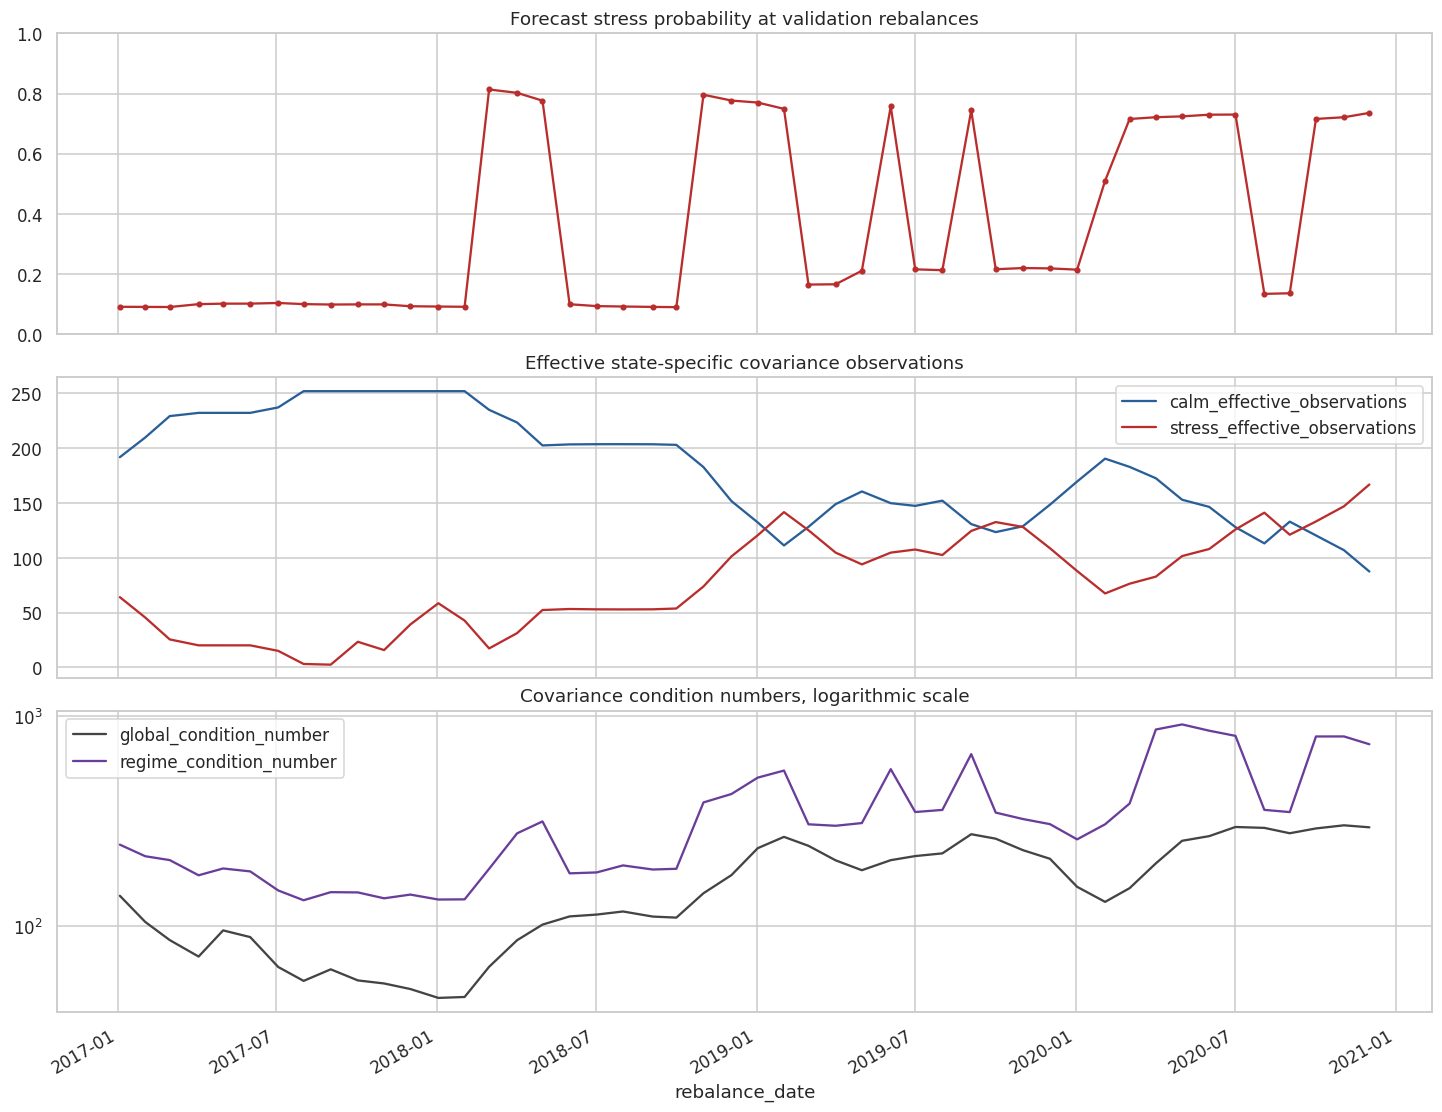

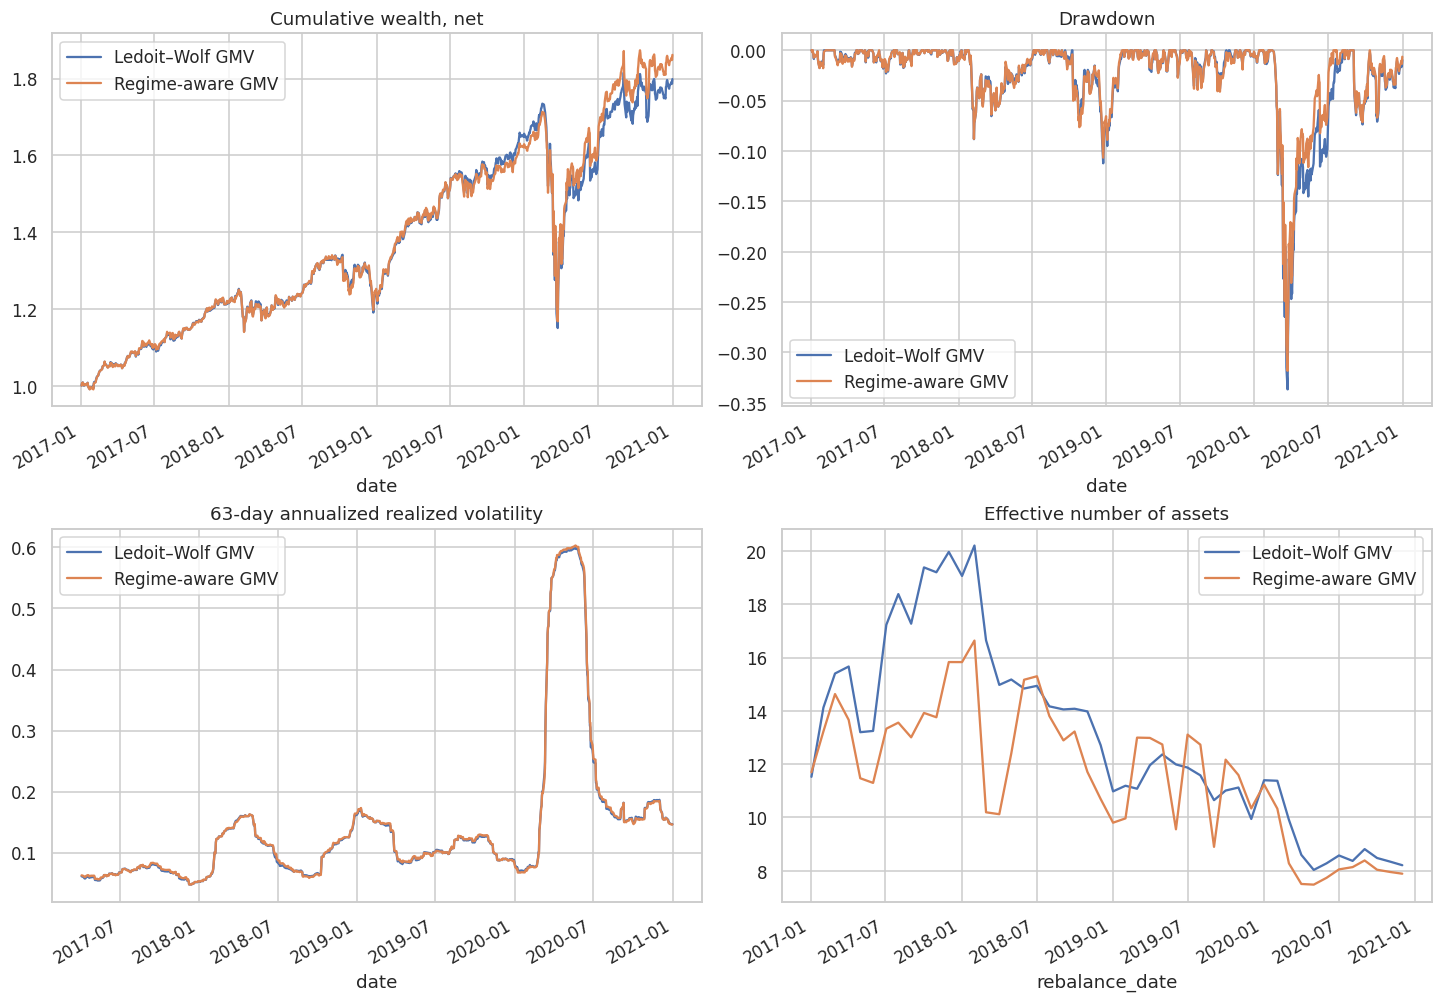

In [ ]:
# Validation diagnostics for article development
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True, constrained_layout=True)
validation_regime_diagnostics["forecast_stress_probability"].plot(
    ax=axes[0], color="#ba2d2d", marker="o", ms=3
)
axes[0].set_ylim(0, 1)
axes[0].set_title("Forecast stress probability at validation rebalances")
validation_regime_diagnostics[["calm_effective_observations", "stress_effective_observations"]].plot(
    ax=axes[1], color=["#295f98", "#ba2d2d"]
)
axes[1].set_title("Effective state-specific covariance observations")
validation_regime_diagnostics[["global_condition_number", "regime_condition_number"]].plot(
    ax=axes[2], logy=True, color=["#444444", "#6a3d9a"]
)
axes[2].set_title("Covariance condition numbers, logarithmic scale")
fig.savefig(FIGURE_DIR / "03_validation_regime_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for label, result in validation_results.items():
    wealth = (1.0 + result.returns["net_return"]).cumprod()
    wealth.plot(ax=axes[0, 0], label=label)
    drawdown_series(result.returns["net_return"]).plot(ax=axes[0, 1], label=label)
    result.returns["net_return"].rolling(63).std() .mul(np.sqrt(TRADING_DAYS)).plot(
        ax=axes[1, 0], label=label
    )
    result.diagnostics["effective_assets"].plot(ax=axes[1, 1], label=label)
axes[0, 0].set_title("Cumulative wealth, net")
axes[0, 1].set_title("Drawdown")
axes[1, 0].set_title("63-day annualized realized volatility")
axes[1, 1].set_title("Effective number of assets")
for axis in axes.flat:
    axis.legend()
fig.savefig(FIGURE_DIR / "04_validation_portfolio_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


## Validation inference and economic attribution

Point estimates alone are not enough. The paired moving-block bootstrap resamples both strategies on identical 20-day blocks, preserving their daily alignment and part of the serial dependence. Differences are always defined as **Pipeline 1 minus Ledoit–Wolf**: negative values favor Pipeline 1 for volatility, CVaR, and drawdown; positive values favor Pipeline 1 for Sharpe.

The second table separates days governed by a forecast stress probability below or above 50%. This attribution uses only the point-in-time probability produced at the preceding rebalance, so it does not classify a day with information learned afterward.


In [ ]:
validation_bootstrap = paired_moving_block_bootstrap(
    baseline_validation.returns["net_return"],
    regime_validation.returns["net_return"],
    BOOTSTRAP_REPLICATIONS,
    BOOTSTRAP_BLOCK_LENGTH,
    SEED,
)
display(validation_bootstrap.style.format({
    "point_difference": "{:.4f}",
    "lower_95": "{:.4f}",
    "upper_95": "{:.4f}",
    "probability_difference_below_zero": "{:.1%}",
}))
validation_bootstrap.to_csv(TABLE_DIR / "validation_paired_block_bootstrap.csv")

validation_stress_probability = (
    validation_regime_diagnostics["forecast_stress_probability"]
    .reindex(split_dates["validation"])
    .ffill()
    .bfill()
)
validation_regime_bucket = pd.Series(
    np.where(validation_stress_probability >= 0.50, "forecast stress", "forecast calm"),
    index=validation_stress_probability.index,
    name="forecast regime",
)

conditional_records = []
for strategy_name, result in validation_results.items():
    for bucket_name in ["forecast calm", "forecast stress"]:
        selected = result.returns.loc[
            validation_regime_bucket.index[validation_regime_bucket == bucket_name],
            "net_return",
        ].dropna()
        _, conditional_cvar = var_cvar(selected, 0.95)
        conditional_records.append({
            "strategy": strategy_name,
            "forecast regime": bucket_name,
            "days": len(selected),
            "annualized mean return": selected.mean() * TRADING_DAYS,
            "annualized volatility": selected.std(ddof=1) * np.sqrt(TRADING_DAYS),
            "Sharpe (zero cash rate)": selected.mean() / selected.std(ddof=1) * np.sqrt(TRADING_DAYS),
            "CVaR 95%": conditional_cvar,
        })
conditional_performance = pd.DataFrame(conditional_records).set_index(["forecast regime", "strategy"])
display(conditional_performance.style.format({
    "annualized mean return": "{:.2%}",
    "annualized volatility": "{:.2%}",
    "Sharpe (zero cash rate)": "{:.3f}",
    "CVaR 95%": "{:.2%}",
}))
conditional_performance.to_csv(TABLE_DIR / "validation_regime_conditioned_performance.csv")


,point_difference,lower_95,upper_95,probability_difference_below_zero
Annualized Volatility,0.0010,-0.0007,0.0027,11.8%
CVaR 95%,-0.0002,-0.0012,0.0006,63.7%
Maximum Drawdown,-0.0184,-0.0405,0.0082,88.1%
Sharpe,0.0427,-0.0572,0.1226,19.6%


,,days,annualized mean return,annualized volatility,Sharpe (zero cash rate),CVaR 95%
forecast regime,strategy,,,,,
forecast calm,Ledoit–Wolf GMV,633,14.16%,9.72%,1.456,1.57%
forecast stress,Ledoit–Wolf GMV,374,20.19%,27.44%,0.736,4.46%
forecast calm,Regime-aware GMV,633,13.30%,9.74%,1.365,1.59%
forecast stress,Regime-aware GMV,374,24.01%,27.61%,0.870,4.43%


In [ ]:
implementation_attribution = pd.DataFrame({
    "forecast regime": np.where(
        validation_regime_diagnostics["forecast_stress_probability"] >= 0.50,
        "forecast stress", "forecast calm",
    ),
    "baseline turnover": baseline_validation.diagnostics["turnover"],
    "pipeline turnover": regime_validation.diagnostics["turnover"],
    "baseline effective assets": baseline_validation.diagnostics["effective_assets"],
    "pipeline effective assets": regime_validation.diagnostics["effective_assets"],
    "baseline maximum weight": baseline_validation.diagnostics["maximum_weight"],
    "pipeline maximum weight": regime_validation.diagnostics["maximum_weight"],
}, index=validation_regime_diagnostics.index)
implementation_attribution["incremental turnover"] = (
    implementation_attribution["pipeline turnover"]
    - implementation_attribution["baseline turnover"]
)
implementation_summary = implementation_attribution.groupby("forecast regime").agg(
    rebalances=("incremental turnover", "size"),
    baseline_turnover=("baseline turnover", "mean"),
    pipeline_turnover=("pipeline turnover", "mean"),
    incremental_turnover=("incremental turnover", "mean"),
    baseline_effective_assets=("baseline effective assets", "mean"),
    pipeline_effective_assets=("pipeline effective assets", "mean"),
    baseline_maximum_weight=("baseline maximum weight", "mean"),
    pipeline_maximum_weight=("pipeline maximum weight", "mean"),
)
display(implementation_summary.style.format({
    "baseline_turnover": "{:.3f}", "pipeline_turnover": "{:.3f}",
    "incremental_turnover": "{:+.3f}",
    "baseline_effective_assets": "{:.2f}", "pipeline_effective_assets": "{:.2f}",
    "baseline_maximum_weight": "{:.2%}", "pipeline_maximum_weight": "{:.2%}",
}))
implementation_summary.to_csv(TABLE_DIR / "validation_implementation_attribution.csv")


,rebalances,baseline_turnover,pipeline_turnover,incremental_turnover,baseline_effective_assets,pipeline_effective_assets,baseline_maximum_weight,pipeline_maximum_weight
forecast regime,,,,,,,,
forecast calm,30,0.256,0.331,+0.074,14.18,12.95,13.57%,14.55%
forecast stress,18,0.291,0.438,+0.148,11.00,9.25,15.00%,15.00%


## Predefined sensitivity panel

This panel is diagnostic rather than a model-selection contest. The primary specification remains fixed. Three transparent perturbations test whether the conclusion depends entirely on one HMM history, one pooling intensity, or omission of between-state mean dispersion:

- five-year rather than ten-year HMM history;
- twice as much pooling toward Ledoit–Wolf;
- inclusion of the between-state mean term in the covariance mixture.

A credible conclusion should have the same qualitative direction across most specifications. The locked test remains untouched.


In [ ]:
def altered_regime_config(**changes) -> RegimeConfig:
    values = asdict(REGIME_CONFIG)
    values.update(changes)
    return RegimeConfig(**values)


sensitivity_specs = {
    "Primary: 10y HMM, kappa=1": REGIME_CONFIG,
    "Five-year HMM": altered_regime_config(hmm_lookback=1260),
    "Stronger pooling: kappa=2": altered_regime_config(pooling_strength=2.0),
    "Include between-state mean": altered_regime_config(include_between_state_mean=True),
}
sensitivity_results = {"Ledoit–Wolf GMV": baseline_validation}
for label, specification in sensitivity_specs.items():
    if specification == REGIME_CONFIG:
        sensitivity_results[label] = regime_validation
    else:
        print(f"Running validation sensitivity: {label}")
        sensitivity_results[label] = run_walk_forward_backtest(
            simple_returns, price_matrix, regime_features,
            split_dates["validation"], BASELINE_CONFIG, specification, "regime_gmv",
        )

sensitivity_metrics = metric_table(sensitivity_results)
sensitivity_columns = [
    "Annualized Volatility", "CVaR 95%", "Maximum Drawdown", "Sharpe",
    "Annualized Turnover", "Total Transaction Costs", "Average Effective Assets",
    "Solver Failures", "HMM Fallbacks",
]
display(format_metric_table(sensitivity_metrics[sensitivity_columns]))
sensitivity_metrics.to_csv(TABLE_DIR / "validation_sensitivity_metrics.csv")


Running validation sensitivity: Five-year HMM
Running validation sensitivity: Stronger pooling: kappa=2
Running validation sensitivity: Include between-state mean


,Annualized Volatility,CVaR 95%,Maximum Drawdown,Sharpe,Annualized Turnover,Total Transaction Costs,Average Effective Assets,Solver Failures,HMM Fallbacks
Ledoit–Wolf GMV,18.40%,2.82%,33.66%,0.891,3.233,1.29%,12.989,0.000,0.000
"Primary: 10y HMM, kappa=1",18.50%,2.80%,31.82%,0.934,4.456,1.78%,11.567,0.000,0.000
Five-year HMM,18.61%,2.82%,32.37%,0.907,4.613,1.84%,11.616,0.000,0.000
Stronger pooling: kappa=2,18.41%,2.79%,31.81%,0.939,4.127,1.65%,11.883,0.000,0.000
Include between-state mean,18.49%,2.80%,31.82%,0.932,4.457,1.78%,11.565,0.000,0.000


## Executive validation panel

This is the colleague-facing decision surface. It distinguishes economic direction, statistical support, and implementation cost instead of reducing the experiment to one performance number. The panel is generated from the tables above and therefore updates automatically when the notebook is rerun.


In [ ]:
baseline_row = validation_metrics.loc["Ledoit–Wolf GMV"]
pipeline_row = validation_metrics.loc["Regime-aware GMV"]
headline_metrics = [
    "Annualized Volatility", "CVaR 95%", "Maximum Drawdown", "Sharpe",
    "Annualized Turnover", "Total Transaction Costs", "Average Effective Assets",
]
executive_comparison = pd.DataFrame({
    "Ledoit–Wolf": baseline_row[headline_metrics],
    "Pipeline 1": pipeline_row[headline_metrics],
    "difference": pipeline_row[headline_metrics] - baseline_row[headline_metrics],
    "relative difference": (
        pipeline_row[headline_metrics] / baseline_row[headline_metrics] - 1.0
    ),
})
display(executive_comparison.style.format({
    "Ledoit–Wolf": "{:.4f}", "Pipeline 1": "{:.4f}",
    "difference": "{:+.4f}", "relative difference": "{:+.1%}",
}))

h1_direction = pipeline_row["Annualized Volatility"] < baseline_row["Annualized Volatility"]
h1_supported = validation_bootstrap.loc["Annualized Volatility", "upper_95"] < 0
h2_direction = (
    pipeline_row["CVaR 95%"] < baseline_row["CVaR 95%"]
    and pipeline_row["Maximum Drawdown"] < baseline_row["Maximum Drawdown"]
)
h2_supported = (
    validation_bootstrap.loc["CVaR 95%", "upper_95"] < 0
    and validation_bootstrap.loc["Maximum Drawdown", "upper_95"] < 0
)
h3_cost_control = (
    pipeline_row["Annualized Turnover"] <= 1.10 * baseline_row["Annualized Turnover"]
    and pipeline_row["Average Effective Assets"] >= 0.90 * baseline_row["Average Effective Assets"]
    and pipeline_row["Mean Target L1 Change"] <= 1.10 * baseline_row["Mean Target L1 Change"]
)
hypothesis_panel = pd.DataFrame([
    {
        "hypothesis": "H1 — lower realized volatility",
        "economic direction": h1_direction,
        "95% bootstrap support": h1_supported,
        "implementation gate": True,
    },
    {
        "hypothesis": "H2 — lower CVaR and drawdown",
        "economic direction": h2_direction,
        "95% bootstrap support": h2_supported,
        "implementation gate": True,
    },
    {
        "hypothesis": "H3 — benefit without material implementation damage",
        "economic direction": h1_direction or h2_direction,
        "95% bootstrap support": np.nan,
        "implementation gate": h3_cost_control,
    },
]).set_index("hypothesis")
display(hypothesis_panel)

if (h1_supported or h2_supported) and h3_cost_control:
    validation_verdict = "VALIDATION PASSED — protocol may be frozen for the locked test"
elif h1_direction or h2_direction:
    validation_verdict = "PROMISING BUT MIXED — downside benefit must be weighed against cost and instability"
else:
    validation_verdict = "VALIDATION NOT PASSED — no primary risk advantage"

display(Markdown(
    f"### Validation verdict: {validation_verdict}\n\n"
    "The locked test remains disabled. Review the extreme-return audit and sensitivity panel, "
    "record the protocol decision, and only then change `RUN_LOCKED_TEST`."
))
executive_comparison.to_csv(TABLE_DIR / "executive_validation_comparison.csv")
hypothesis_panel.to_csv(TABLE_DIR / "executive_hypothesis_panel.csv")


,Ledoit–Wolf,Pipeline 1,difference,relative difference
Annualized Volatility,0.1840,0.1850,+0.0010,+0.5%
CVaR 95%,0.0282,0.0280,-0.0002,-0.7%
Maximum Drawdown,0.3366,0.3182,-0.0184,-5.5%
Sharpe,0.8912,0.9339,+0.0427,+4.8%
Annualized Turnover,3.2326,4.4558,+1.2232,+37.8%
Total Transaction Costs,0.0129,0.0178,+0.0049,+37.8%
Average Effective Assets,12.9892,11.5666,-1.4226,-11.0%


,economic direction,95% bootstrap support,implementation gate
hypothesis,,,
H1 — lower realized volatility,False,False,True
H2 — lower CVaR and drawdown,True,False,True
H3 — benefit without material implementation damage,True,NaN,False


### Validation verdict: PROMISING BUT MIXED — downside benefit must be weighed against cost and instability

The locked test remains disabled. Review the extreme-return audit and sensitivity panel, record the protocol decision, and only then change `RUN_LOCKED_TEST`.

## Locked test

Run the next cell only after the validation diagnostics and all modelling choices have been accepted and documented. The notebook deliberately refuses to execute the test unless `RUN_LOCKED_TEST = True` is set in the configuration cell.


In [ ]:
test_results = None
test_metrics = None
if not RUN_LOCKED_TEST:
    display(Markdown(
        "**Locked test not executed.** Freeze the Pipeline 1 protocol, then set "
        "`RUN_LOCKED_TEST = True` and rerun from the configuration cell."
    ))
else:
    test_results = {}
    for strategy, label in [
        ("ledoit_wolf_gmv", "Ledoit–Wolf GMV"),
        ("regime_gmv", "Regime-aware GMV"),
    ]:
        print(f"Running locked test: {label}")
        test_results[label] = run_walk_forward_backtest(
            simple_returns, price_matrix, regime_features,
            split_dates["test"], BASELINE_CONFIG, REGIME_CONFIG, strategy,
        )
    test_metrics = metric_table(test_results)
    display(format_metric_table(test_metrics))
    test_metrics.to_csv(TABLE_DIR / "locked_test_metrics.csv")


**Locked test not executed.** Freeze the Pipeline 1 protocol, then set `RUN_LOCKED_TEST = True` and rerun from the configuration cell.

In [ ]:
test_bootstrap = None
if test_results is not None:
    test_bootstrap = paired_moving_block_bootstrap(
        test_results["Ledoit–Wolf GMV"].returns["net_return"],
        test_results["Regime-aware GMV"].returns["net_return"],
        BOOTSTRAP_REPLICATIONS,
        BOOTSTRAP_BLOCK_LENGTH,
        SEED,
    )
    display(test_bootstrap)
    test_bootstrap.to_csv(TABLE_DIR / "locked_test_paired_block_bootstrap.csv")


In [ ]:
if test_results is not None:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    for label, result in test_results.items():
        returns = result.returns["net_return"]
        (1.0 + returns).cumprod().plot(ax=axes[0, 0], label=label)
        drawdown_series(returns).plot(ax=axes[0, 1], label=label)
        returns.rolling(63).std().mul(np.sqrt(TRADING_DAYS)).plot(ax=axes[1, 0], label=label)
        result.diagnostics["turnover"].plot(ax=axes[1, 1], label=label, marker="o", ms=2)
    axes[0, 0].set_title("Locked-test cumulative wealth, net")
    axes[0, 1].set_title("Locked-test drawdown")
    axes[1, 0].set_title("63-day annualized realized volatility")
    axes[1, 1].set_title("Rebalance turnover")
    for axis in axes.flat:
        axis.legend()
    fig.savefig(FIGURE_DIR / "05_locked_test_portfolio_comparison.png", dpi=180, bbox_inches="tight")
    plt.show()

    weight_difference = (
        test_results["Regime-aware GMV"].target_weights
        - test_results["Ledoit–Wolf GMV"].target_weights
    )
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(weight_difference.T, cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "Weight difference"})
    ax.set_title("Pipeline 1 minus baseline target weights")
    ax.set_xlabel("Rebalance date")
    ax.set_ylabel("Security")
    fig.savefig(FIGURE_DIR / "06_weight_differences.png", dpi=180, bbox_inches="tight")
    plt.show()


## Integrity audit and article-output bundle

The final audit verifies chronology, covariance/HMM cutoff dates, weight feasibility, gross-to-net reconciliation, and execution status. Tables, figures, configuration, and a machine-readable audit are collected in `pipeline1_article_outputs`.


In [ ]:
audit_records = [
    {
        "check": "Strict split chronology",
        "passed": bool(
            split_ranges.loc["train", "end"] < split_ranges.loc["validation", "start"]
            and split_ranges.loc["validation", "end"] < split_ranges.loc["test", "start"]
        ),
        "evidence": "max(train) < min(validation) < max(validation) < min(test)",
    },
    {
        "check": "Validation covariance history precedes formation",
        "passed": all((result.diagnostics["history_end"] < result.diagnostics.index).all()
                      for result in validation_results.values()),
        "evidence": "Every recorded history_end is earlier than its rebalance date",
    },
    {
        "check": "Validation weights are feasible",
        "passed": all(
            np.allclose(result.target_weights.sum(axis=1), 1.0, atol=1e-8)
            and result.target_weights.min().min() >= -1e-10
            and result.target_weights.max().max() <= BASELINE_CONFIG.max_weight + 1e-7
            for result in validation_results.values()
        ),
        "evidence": "Weights sum to one, remain long-only, and respect the frozen cap",
    },
    {
        "check": "Gross-to-net return reconciliation",
        "passed": all(np.allclose(
            result.returns["net_return"],
            result.returns["gross_return"] - result.returns["transaction_cost"],
        ) for result in validation_results.values()),
        "evidence": "net = gross - transaction cost",
    },
    {
        "check": "Validation inference completed",
        "passed": bool(
            len(validation_bootstrap) == 4
            and np.isfinite(validation_bootstrap.to_numpy()).all()
        ),
        "evidence": "Paired 20-day moving-block bootstrap contains four finite metric rows",
    },
    {
        "check": "Sensitivity runs remained operational",
        "passed": bool(
            sensitivity_metrics["Solver Failures"].sum() == 0
            and sensitivity_metrics["HMM Fallbacks"].sum() == 0
        ),
        "evidence": "No optimizer failures or HMM fallbacks across predefined specifications",
    },
    {
        "check": "Extreme returns explicitly disclosed",
        "passed": bool(
            len(extreme_return_events)
            == int(simple_returns.abs().gt(0.20).sum().sum())
        ),
        "evidence": "Every adjusted-price return above 20% is present in the audit table",
    },
    {
        "check": "Locked test execution",
        "passed": bool(RUN_LOCKED_TEST and test_results is not None),
        "evidence": "False is expected during model development",
    },
]
integrity_audit = pd.DataFrame(audit_records).set_index("check")
display(integrity_audit)
integrity_audit.to_csv(TABLE_DIR / "integrity_audit.csv")

with open(ARTICLE_DIR / "frozen_configuration.json", "w", encoding="utf-8") as file:
    json.dump({
        "baseline": asdict(BASELINE_CONFIG),
        "pipeline_1": asdict(REGIME_CONFIG),
        "seed": SEED,
        "run_locked_test": RUN_LOCKED_TEST,
    }, file, indent=2)

state_summary.to_csv(TABLE_DIR / "regime_state_summary.csv")
transition.to_csv(TABLE_DIR / "regime_transition_matrix.csv")
feature_definitions.to_csv(TABLE_DIR / "feature_definitions.csv")
archive_path = shutil.make_archive(str(ARTICLE_DIR), "zip", root_dir=ARTICLE_DIR)
print("Article-output bundle:", archive_path)


,passed,evidence
check,,
Strict split chronology,True,max(train) < min(validation) < max(validation)...
Validation covariance history precedes formation,True,Every recorded history_end is earlier than its...
Validation weights are feasible,True,"Weights sum to one, remain long-only, and resp..."
Gross-to-net return reconciliation,True,net = gross - transaction cost
Validation inference completed,True,Paired 20-day moving-block bootstrap contains ...
Sensitivity runs remained operational,True,No optimizer failures or HMM fallbacks across ...
Extreme returns explicitly disclosed,True,Every adjusted-price return above 20% is prese...
Locked test execution,False,False is expected during model development


Article-output bundle: /content/pipeline1_article_outputs.zip


## Interpretation checklist for the article

Before claiming that Pipeline 1 improves portfolio allocation, answer all of the following:

1. **Economic identity:** Does the stress state have higher volatility, deeper drawdown, and stronger cross-sectional correlation?
2. **Persistence:** Are transition probabilities and expected durations plausible rather than degenerate?
3. **Sample adequacy:** Does the stress covariance retain enough effective observations after soft weighting?
4. **Incremental risk:** Are volatility, CVaR, and drawdown lower than the frozen Ledoit–Wolf baseline?
5. **Statistical uncertainty:** Do paired block-bootstrap intervals support the key differences?
6. **Implementation cost:** Do turnover and costs erase the risk advantage?
7. **Portfolio stability:** Are concentration, effective breadth, and target-weight changes acceptable?
8. **Numerical stability:** Are condition numbers, eigenvalues, HMM convergence, and solver failures controlled?
9. **Robustness:** Do conclusions survive three states, alternative HMM windows, alternative feature windows, zero/mean mixture treatment, and an EWMA-GMV comparator?

**Primary limitation.** The experiment identifies statistical market states inside a surviving 50-stock panel. It does not establish causal regimes, eliminate survivorship bias, or prove that the same state process applies to a different market or universe.
